In [37]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw
from intersect_detection import get_bounding_boxes

(-0.5, 639.5, 639.5, -0.5)

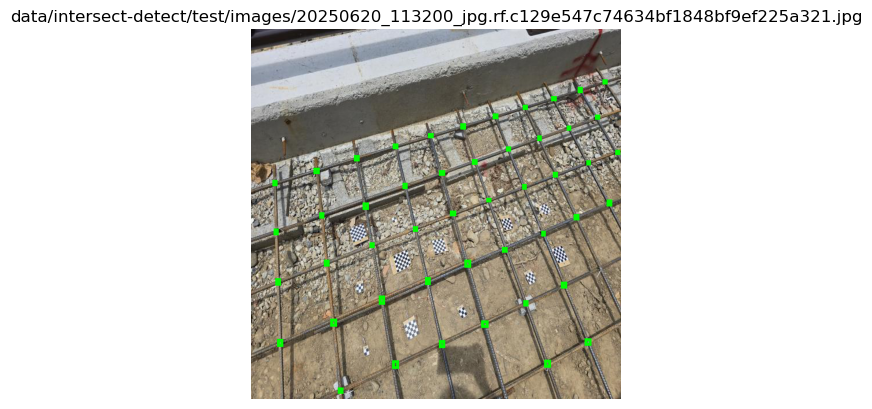

In [38]:
image_path = "data/intersect-detect/test/images/20250620_115012_jpg.rf.239a32ab7bcbefe30fb9f388607d7048.jpg"
image_path = "data/intersect-detect/test/images/20250620_113200_jpg.rf.c129e547c74634bf1848bf9ef225a321.jpg"
model_path = "runs/detect/tune/weights/best.pt"

image = Image.open(image_path)
draw = ImageDraw.Draw(image)

bounding_boxes = get_bounding_boxes(image_path, model_path)
vertices = []
for box in bounding_boxes:
    x_center = (box[0] + box[2]) / 2
    y_center = (box[1] + box[3]) / 2
    vertices.append((x_center, y_center))
    draw.rectangle(box, outline="lime", width=5)
vertices = np.array(vertices)

# Display
fig = plt.subplot()
fig.imshow(image)
fig.set_title(f"{image_path}")
fig.axis('off')

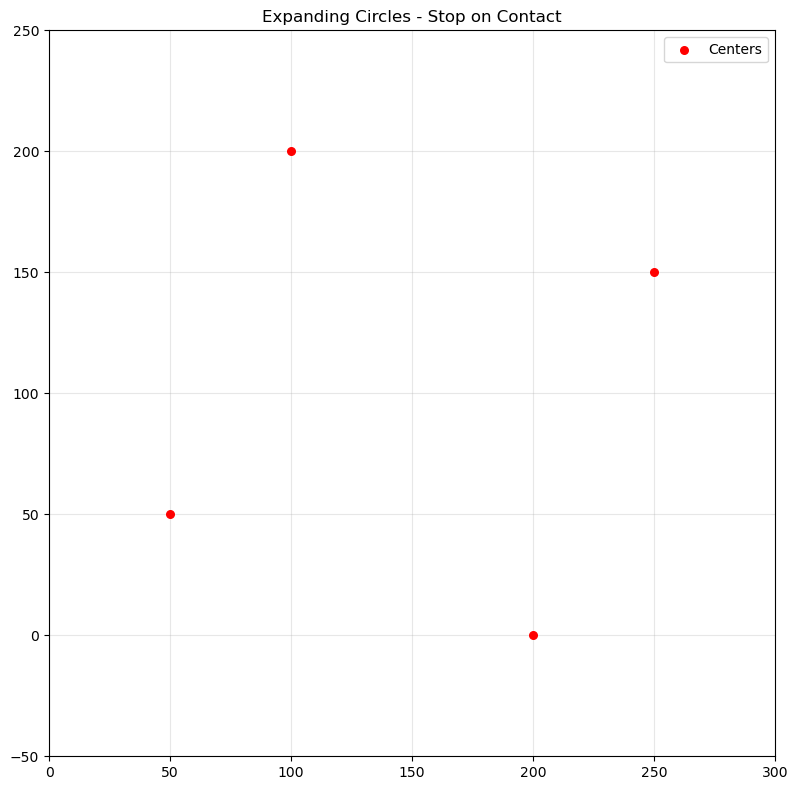

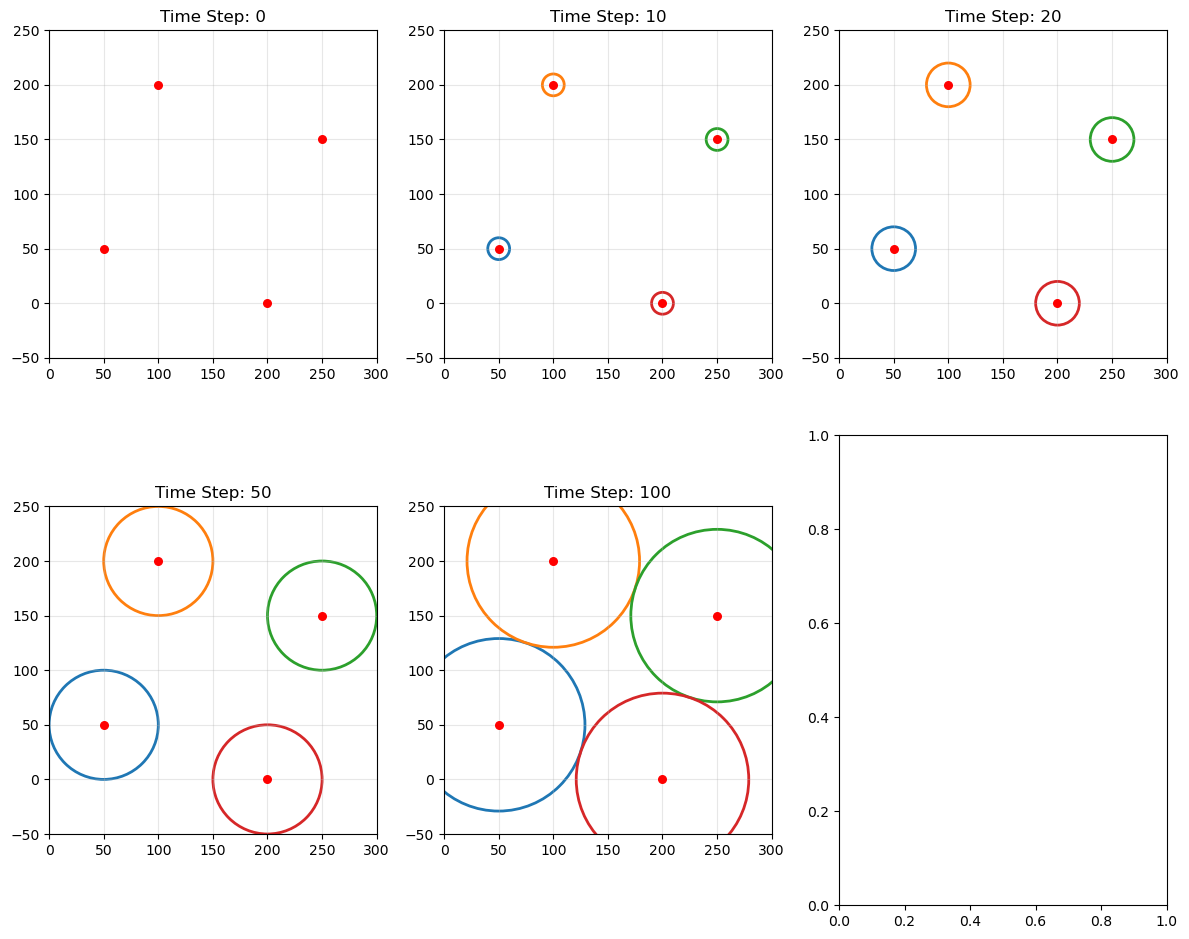

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import math

class ExpandingCircles:
    def __init__(self, coordinates):
        self.coordinates = np.array(coordinates)
        self.radii = np.zeros(len(coordinates))
        self.max_radii = np.full(len(coordinates), np.inf)
        self.growth_rate = 1.0
        self.active = np.ones(len(coordinates), dtype=bool)
        
    def update_circles(self):
        # Check for collisions between all pairs of circles
        for i in range(len(self.coordinates)):
            if not self.active[i]:
                continue
                
            for j in range(i + 1, len(self.coordinates)):
                if not self.active[j]:
                    continue
                    
                # Calculate distance between centers
                dist = np.linalg.norm(self.coordinates[i] - self.coordinates[j])
                
                # If circles would overlap in next frame, stop them
                if self.radii[i] + self.radii[j] + 2 * self.growth_rate >= dist:
                    # Calculate maximum radius for each circle
                    max_radius_i = (dist - self.radii[j]) / 2
                    max_radius_j = (dist - self.radii[i]) / 2
                    
                    self.max_radii[i] = min(self.max_radii[i], max_radius_i)
                    self.max_radii[j] = min(self.max_radii[j], max_radius_j)
        
        # Update radii for active circles
        for i in range(len(self.coordinates)):
            if self.active[i] and self.radii[i] < self.max_radii[i]:
                self.radii[i] = min(self.radii[i] + self.growth_rate, self.max_radii[i])
            else:
                self.active[i] = False

def create_expanding_circles_animation(coordinates, figsize=(10, 8)):
    """
    Create an animation of expanding circles that stop when they touch.
    
    Parameters:
    coordinates: List of (x, y) tuples representing circle centers
    figsize: Figure size tuple
    """
    
    circles = ExpandingCircles(coordinates)
    
    # Set up the plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Calculate plot bounds
    coords_array = np.array(coordinates)
    x_min, x_max = coords_array[:, 0].min() - 50, coords_array[:, 0].max() + 50
    y_min, y_max = coords_array[:, 1].min() - 50, coords_array[:, 1].max() + 50
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_title('Expanding Circles - Stop on Contact')
    
    # Plot center points
    ax.scatter(coords_array[:, 0], coords_array[:, 1], 
              c='red', s=30, zorder=10, label='Centers')
    
    # Initialize circle patches
    circle_patches = []
    for i, (x, y) in enumerate(coordinates):
        circle = plt.Circle((x, y), 0, fill=False, 
                           color=plt.cm.tab10(i), linewidth=2)
        ax.add_patch(circle)
        circle_patches.append(circle)
    
    def animate(frame):
        circles.update_circles()
        
        # Update circle patches
        for i, patch in enumerate(circle_patches):
            patch.set_radius(circles.radii[i])
            # Change color if circle stopped growing
            if not circles.active[i]:
                patch.set_color('gray')
                patch.set_alpha(0.7)
        
        return circle_patches
    
    # Create animation
    anim = FuncAnimation(fig, animate, frames=200, interval=100, 
                        blit=False, repeat=True)
    
    ax.legend()
    plt.tight_layout()
    return fig, anim

# Example usage with sample coordinates
coordinates = [
    (50, 50),
    (100, 200),
    (250, 150),
    (200, 0),
]

# Create and display the animation
fig, anim = create_expanding_circles_animation(coordinates)
plt.show()

# For static visualization at different time steps
def plot_static_circles(coordinates, time_steps=[0, 10, 20, 50, 100]):
    """Plot circles at different time steps"""
    
    fig, axes = plt.subplots(2, 3, figsize=(12, 10))
    axes = axes.ravel()
    
    for idx, steps in enumerate(time_steps):
        circles = ExpandingCircles(coordinates)
        
        # Run simulation for specified steps
        for _ in range(steps):
            circles.update_circles()
        
        ax = axes[idx]
        coords_array = np.array(coordinates)
        
        # Set plot bounds
        x_min, x_max = coords_array[:, 0].min() - 50, coords_array[:, 0].max() + 50
        y_min, y_max = coords_array[:, 1].min() - 50, coords_array[:, 1].max() + 50
        
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        ax.set_title(f'Time Step: {steps}')
        
        # Plot centers
        ax.scatter(coords_array[:, 0], coords_array[:, 1], 
                  c='red', s=30, zorder=10)
        
        # Plot circles
        for i, (x, y) in enumerate(coordinates):
            if circles.radii[i] > 0:
                circle = plt.Circle((x, y), circles.radii[i], 
                                  fill=False, color=plt.cm.tab10(i), 
                                  linewidth=2)
                ax.add_patch(circle)
    
    plt.tight_layout()
    plt.show()

# Show static progression
plot_static_circles(coordinates)